# 01. 데이터 품질검사 결과 검증 (Data Validation)

> ⚠️ **가상 데이터 프로젝트**: 이 노트북에서 다루는 모든 수치는 `FANLOG` 포트폴리오 프로젝트를 위해 생성한 가상 데이터를 대상으로 한다. 실제 팬덤 플랫폼의 데이터가 아니다.

## 목적

`sql/quality_checks/run_all.sql`에 정의된 5개 그룹, 87개 세부 품질검사 규칙(DQ-01~10, ET-DQ-01~28 중 구현된 항목)의 결과를 Python에서 재현하고 표·차트로 정리한다.

- 기준 문서: `docs/PRD.md` 15.1절(자동 품질검사), 19.2절("DQ-01~DQ-10의 핵심 오류가 0건이다")
- 이미 `sql/quality_checks/run_all.sql`을 psql로 직접 실행해 전수 검증을 마쳤다(`docs/decisions_log.md` 9절 참고). 이 노트북은 같은 SQL을 SQLAlchemy로 Python에서 실행해 결과를 재현하고, 그중 대표적인 규칙 3개는 SQL과 별개로 pandas 코드를 새로 작성해 **독립적으로 교차검증**한다.
- 요약 섹션을 맨 위에 배치했다(아래 "## 요약" 참고). 상세 근거는 그 아래 이어진다.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 차트에서 한글 레이블이 깨지지 않도록 Windows 기본 한글 폰트로 지정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from analysis.db import get_engine  # noqa: E402

engine = get_engine()
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
print("DB 연결 완료:", engine.url.database)


DB 연결 완료: fanlog


## 요약 (Summary)

먼저 87개 규칙 전체를 한 번에 실행한 결과를 확인한다. 상세 내역은 이 아래 섹션에서 이어진다.

In [2]:
sql_text = (PROJECT_ROOT / "sql" / "quality_checks" / "run_all.sql").read_text(encoding="utf-8")

# run_all.sql은 (1) 87개 항목 통합 요약 쿼리, (2) ET-DQ-28 참고용 집계 쿼리를 먼저 실행한 뒌
# \i 로 001~005 파일 전체를 다시 실행한다. 여기서는 앞의 두 쿼리(세미콜론 기준 첫 2개 statement)만
# 그대로 가져와 Python에서 재실행한다.
marker = "\n\\i "
pre_i_text = sql_text.split(marker)[0]
statements = [s.strip() for s in pre_i_text.split(";")][:2]

summary_query, reference_query = statements
qa_df = pd.read_sql(summary_query, engine)
pending_reference_df = pd.read_sql(reference_query, engine)

print(f"총 세부 항목 수: {len(qa_df)}개")
qa_df.head()


총 세부 항목 수: 87개


,group_no,source_file,rule_id,target,violation_count
0,1,001_keys_and_referential_integrity.sql,DQ-01,bridge_user_artist_follow,0
1,1,001_keys_and_referential_integrity.sql,DQ-01,dim_activity_phase,0
2,1,001_keys_and_referential_integrity.sql,DQ-01,dim_artist,0
3,1,001_keys_and_referential_integrity.sql,DQ-01,dim_content,0
4,1,001_keys_and_referential_integrity.sql,DQ-01,dim_product,0


In [3]:
total_rules = len(qa_df)
failed = qa_df[qa_df["violation_count"] > 0]

if len(failed) == 0:
    print(f"[PASS] 전체 {total_rules}개 세부 항목 위반 0건 (100% 통과)")
else:
    print(f"[FAIL] {len(failed)}개 항목에서 위반 발견:")
    print(failed)

print()
print("그룹별(파일별) 항목 수:")
print(qa_df.groupby(["group_no", "source_file"]).size().rename("rule_item_count"))


[PASS] 전체 87개 세부 항목 위반 0건 (100% 통과)

그룹별(파일별) 항목 수:
group_no  source_file                           
1         001_keys_and_referential_integrity.sql    51
2         002_temporal_order.sql                    15
3         003_allowed_values.sql                     6
4         004_commerce_integrity.sql                10
5         005_timezone_consistency.sql               5
Name: rule_item_count, dtype: int64


## 그룹별 위반 건수 (차트)

5개 품질검사 그룹(001~005 파일) 각각의 위반 건수 합계를 막대그래프로 보여준다. 전부 0이어야 정상이다.


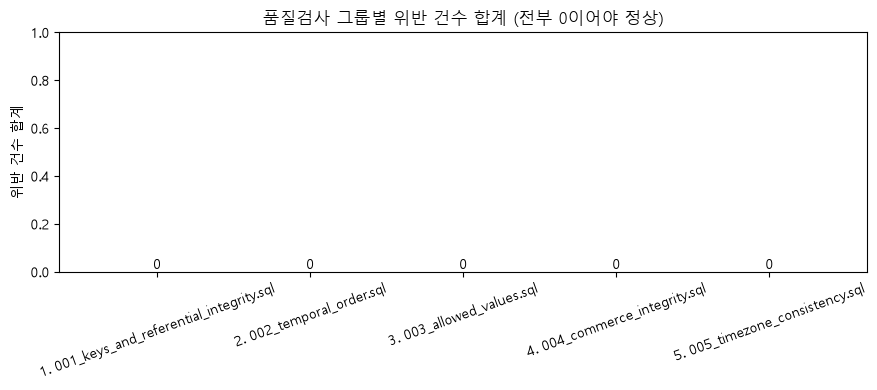

In [4]:
group_summary = (
    qa_df.groupby(["group_no", "source_file"])["violation_count"]
    .sum()
    .reset_index()
    .sort_values("group_no")
)
group_summary["label"] = group_summary["group_no"].astype(str) + ". " + group_summary["source_file"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(group_summary["label"], group_summary["violation_count"], color="#4C9F70")
ax.set_ylim(0, 1)  # 전부 0이므로 y축을 좁게 고정해 "0"이라는 사실 자체가 보이게 한다
ax.set_ylabel("위반 건수 합계")
ax.set_title("품질검사 그룹별 위반 건수 합계 (전부 0이어야 정상)")
ax.tick_params(axis="x", rotation=20)
for bar, val in zip(bars, group_summary["violation_count"]):
    ax.annotate(str(int(val)), (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 전체 87개 세부 항목 상세표

규칙 ID·대상·위반 건수를 그룹 순서대로 전부 나열한다. `violation_count`가 0이 아닌 행이 있으면 빨간색으로 표시된다(현재는 없어야 한다).


In [5]:
def _highlight_nonzero(val):
    return "background-color: #f8d7da; color: #842029; font-weight: bold" if val > 0 else ""

qa_df.sort_values(["group_no", "rule_id", "target"]).style.map(
    _highlight_nonzero, subset=["violation_count"]
)


,group_no,source_file,rule_id,target,violation_count
0,1,001_keys_and_referential_integrity.sql,DQ-01,bridge_user_artist_follow,0
1,1,001_keys_and_referential_integrity.sql,DQ-01,dim_activity_phase,0
2,1,001_keys_and_referential_integrity.sql,DQ-01,dim_artist,0
3,1,001_keys_and_referential_integrity.sql,DQ-01,dim_content,0
4,1,001_keys_and_referential_integrity.sql,DQ-01,dim_product,0
5,1,001_keys_and_referential_integrity.sql,DQ-01,dim_user,0
6,1,001_keys_and_referential_integrity.sql,DQ-01,fact_artist_activity,0
7,1,001_keys_and_referential_integrity.sql,DQ-01,fact_message_subscription,0
8,1,001_keys_and_referential_integrity.sql,DQ-01,fact_order,0
9,1,001_keys_and_referential_integrity.sql,DQ-01,fact_order_item,0


## 참고용: ET-DQ-28 (pending 주문 집계, 위반 아님)

`fact_order.status='pending'`으로 분석 기간이 끝난 주문 수다. `docs/decisions_log.md` 5.13절의 "열린 퍼널" 설계상 정상적으로 발생하는 상태이므로 위 87개 항목에는 포함하지 않고 참고용으로만 별도 표시한다.


In [6]:
pending_count = int(pending_reference_df.iloc[0, 0])
print(f"pending 상태 주문 수 (참고용, 위반 아님): {pending_count}건")


pending 상태 주문 수 (참고용, 위반 아님): 160건


## 독립 교차검증 (SQL과 별개로 pandas 코드를 새로 작성)

위 결과는 이미 검증된 `run_all.sql`을 그대로 재실행한 것이라, "같은 SQL을 두 번 실행"한 것 이상의 추가 증거는 아니다.
아래 3개는 SQL을 전혀 참고하지 않고 원본 테이블을 pandas로 직접 읽어 **다른 방식으로 계산**한 결과이며, 위 표의 해당 항목과 값이 일치하는지 비교한다.


In [7]:
# 교차검증 1) DQ-01: 11개 테이블 기본키 중복 여부 (pandas .duplicated()로 재계산)
pk_columns = {
    "dim_artist": "artist_id",
    "dim_user": "user_id",
    "dim_content": "content_id",
    "dim_product": "product_id",
    "dim_activity_phase": "phase_id",
    "bridge_user_artist_follow": "follow_id",
    "fact_message_subscription": "subscription_id",
    "fact_artist_activity": "activity_id",
    "fact_order": "transaction_id",
    "fact_order_item": "order_item_id",
    "fact_user_event": "event_id",
}

pk_check_rows = []
for table, pk in pk_columns.items():
    col = pd.read_sql(f"SELECT {pk} FROM {table};", engine)[pk]
    pk_check_rows.append({"table": table, "pk_column": pk, "duplicate_count_pandas": int(col.duplicated().sum())})

pk_check_df = pd.DataFrame(pk_check_rows)
sql_dq01 = qa_df[qa_df["rule_id"] == "DQ-01"][["target", "violation_count"]].rename(
    columns={"target": "table", "violation_count": "duplicate_count_sql"}
)
pk_compare = pk_check_df.merge(sql_dq01, on="table", how="left")
pk_compare["match"] = pk_compare["duplicate_count_pandas"] == pk_compare["duplicate_count_sql"]
print("DQ-01 교차검증 (pandas 재계산 vs SQL 결과):")
pk_compare


DQ-01 교차검증 (pandas 재계산 vs SQL 결과):


,table,pk_column,duplicate_count_pandas,duplicate_count_sql,match
0,dim_artist,artist_id,0,0,True
1,dim_user,user_id,0,0,True
2,dim_content,content_id,0,0,True
3,dim_product,product_id,0,0,True
4,dim_activity_phase,phase_id,0,0,True
5,bridge_user_artist_follow,follow_id,0,0,True
6,fact_message_subscription,subscription_id,0,0,True
7,fact_artist_activity,activity_id,0,0,True
8,fact_order,transaction_id,0,0,True
9,fact_order_item,order_item_id,0,0,True


In [8]:
assert pk_compare["match"].all(), "pandas로 재계산한 기본키 중복 건수가 SQL 결과와 다릅니다."
print("[PASS] 11개 테이블 전부 pandas 재계산 결과와 SQL 결과가 일치 (전부 0건)")


[PASS] 11개 테이블 전부 pandas 재계산 결과와 SQL 결과가 일치 (전부 0건)


In [9]:
# 교차검증 2) DQ-03 예시: fact_user_event.user_id -> dim_user 외래키 고아 행 (pandas isin으로 재계산)
dim_user_ids = pd.read_sql("SELECT user_id FROM dim_user;", engine)["user_id"]
event_user_ids = pd.read_sql("SELECT user_id FROM fact_user_event;", engine)["user_id"]

orphan_count_pandas = int((~event_user_ids.isin(dim_user_ids)).sum())
sql_row = qa_df[(qa_df["rule_id"] == "DQ-03") & (qa_df["target"] == "fact_user_event.user_id -> dim_user")]
orphan_count_sql = int(sql_row["violation_count"].iloc[0])

print(f"pandas로 재계산한 고아 행 수: {orphan_count_pandas}")
print(f"SQL 결과의 고아 행 수: {orphan_count_sql}")
assert orphan_count_pandas == orphan_count_sql
print("[PASS] 일치")


pandas로 재계산한 고아 행 수: 0
SQL 결과의 고아 행 수: 0
[PASS] 일치


In [10]:
# 교차검증 3) DQ-10 예시: dim_user의 UTC->KST 파생 일자 일치 여부 (pandas dt.tz_convert로 재계산)
dim_user_ts = pd.read_sql(
    "SELECT user_id, signup_timestamp_utc, signup_date_kst FROM dim_user;", engine
)
dim_user_ts["signup_timestamp_utc"] = pd.to_datetime(dim_user_ts["signup_timestamp_utc"], utc=True)
dim_user_ts["expected_kst_date_pandas"] = (
    dim_user_ts["signup_timestamp_utc"].dt.tz_convert("Asia/Seoul").dt.date
)
dim_user_ts["signup_date_kst"] = pd.to_datetime(dim_user_ts["signup_date_kst"]).dt.date

mismatch_count_pandas = int((dim_user_ts["expected_kst_date_pandas"] != dim_user_ts["signup_date_kst"]).sum())
sql_row = qa_df[(qa_df["rule_id"] == "DQ-10/ET-DQ-13") & (qa_df["target"] == "dim_user.signup_timestamp_utc vs signup_date_kst")]
mismatch_count_sql = int(sql_row["violation_count"].iloc[0])

print(f"pandas로 재계산한 타임존 불일치 건수: {mismatch_count_pandas}")
print(f"SQL 결과의 타임존 불일치 건수: {mismatch_count_sql}")
assert mismatch_count_pandas == mismatch_count_sql
print("[PASS] 일치 (decisions_log.md 5.10절·5.14절 타임존 버그 재발 없음, pandas 기준으로도 재확인됨)")


pandas로 재계산한 타임존 불일치 건수: 0
SQL 결과의 타임존 불일치 건수: 0
[PASS] 일치 (decisions_log.md 5.10절·5.14절 타임존 버그 재발 없음, pandas 기준으로도 재확인됨)


## 결론

- SQL 품질검사 5개 그룹, 87개 세부 항목 전부 위반 0건 (Python/SQLAlchemy로 재실행해도 동일).
- ET-DQ-28(pending 주문, 160건 내외)은 위반이 아니라 열린 퍼널 설계상 정상 발생하는 상태.
- 대표 규칙 3개(DQ-01 기본키 중복, DQ-03 외래키 고아 행, DQ-10 타임존 일치)는 SQL 코드를 참고하지 않고 pandas로 독립적으로 다시 계산했으며, 모두 SQL 결과와 정확히 일치했다.
- 따라서 이후 노트북(02, 03)에서는 이 데이터의 기본적인 무결성이 확보된 상태로 분석을 진행한다.
